In [539]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

# Часть 1. Построение и анализ простой динамической модели

## 1. Задайте параметры

In [540]:
N = 1000            # общее число пользователей
I0 = 10             # сначала информацию распространяют 10 человек
R0 = 0              # перестали распространять — пока никого
S0 = N - I0 - R0    # остальные ничего не знают

beta = 0.0005       # коэффициент передачи
gamma = 0.1         # коэффициент затухания
T = 100             # число шагов

## 2. Реализуйте итерационный процесс на 50–100 шагов

In [541]:
def simulate(beta, gamma, S0, I0, R0, T, safe=False):
    S, I, R = [S0], [I0], [R0]
    for t in range(T):
        new_inf = beta * S[t] * I[t]     # сколько человек узнали информацию на этом шаге
        new_rec = gamma * I[t]           # сколько человек перестали её распространять
        if safe:                         # «ограничение шага» (нужно в части 2)
            new_inf = min(new_inf, S[t])
            new_rec = min(new_rec, I[t])
        S.append(S[t] - new_inf)
        I.append(I[t] + new_inf - new_rec)
        R.append(R[t] + new_rec)
    return np.array(S), np.array(I), np.array(R)


S, I, R = simulate(beta, gamma, S0, I0, R0, T)

print("Проверка S+I+R=N, максимальное отклонение:", np.max(np.abs(S + I + R - N)))
print(f"Шаг 0:   S={S[0]:.1f}  I={I[0]:.1f}  R={R[0]:.1f}")
print(f"Шаг 100: S={S[-1]:.1f}  I={I[-1]:.1f}  R={R[-1]:.1f}")

Проверка S+I+R=N, максимальное отклонение: 4.547473508864641e-13
Шаг 0:   S=990.0  I=10.0  R=0.0
Шаг 100: S=4.3  I=0.1  R=995.6


## 3. Постройте графики St, It, Rt от времени t

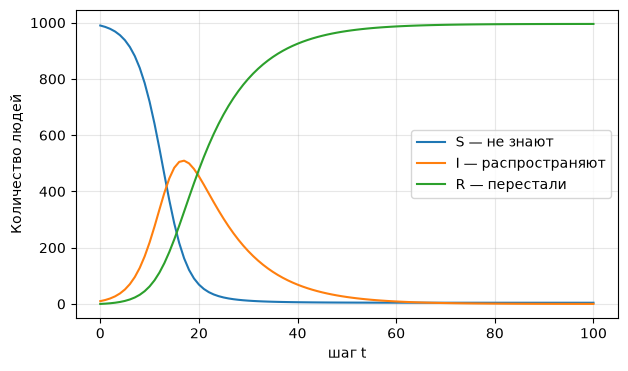

In [542]:
t = np.arange(T + 1)
plt.figure(figsize=(7, 4))
plt.plot(t, S, label="S — не знают")
plt.plot(t, I, label="I — распространяют")
plt.plot(t, R, label="R — перестали")
#plt.ylim(0, N)
plt.xlabel("шаг t"); plt.ylabel("Количество людей")
plt.legend(); plt.grid(alpha=0.3)
plt.show()

## 4. Проведите эксперименты

In [543]:
def report(name, S, I):
    охват = (N - S[-1]) / N
    print(f"{name:14s} пик I = {I.max():6.1f} (шаг {I.argmax():3d})   охват = {охват:6.1%}   I на шаге 100 = {I[-1]:6.1f}")

### 4.1 измените β (увеличьте/уменьшите в 2–5 раз)

beta=0.0001    пик I =   10.0 (шаг   0)   охват =   8.9%   I на шаге 100 =    5.9
beta=0.00025   пик I =  245.2 (шаг  34)   охват =  89.9%   I на шаге 100 =    3.6
beta=0.001     пик I =  739.3 (шаг   9)   охват = 100.0%   I на шаге 100 =    0.1
beta=0.0025    пик I =  960.1 (шаг   5)   охват = 100.0%   I на шаге 100 =    0.0


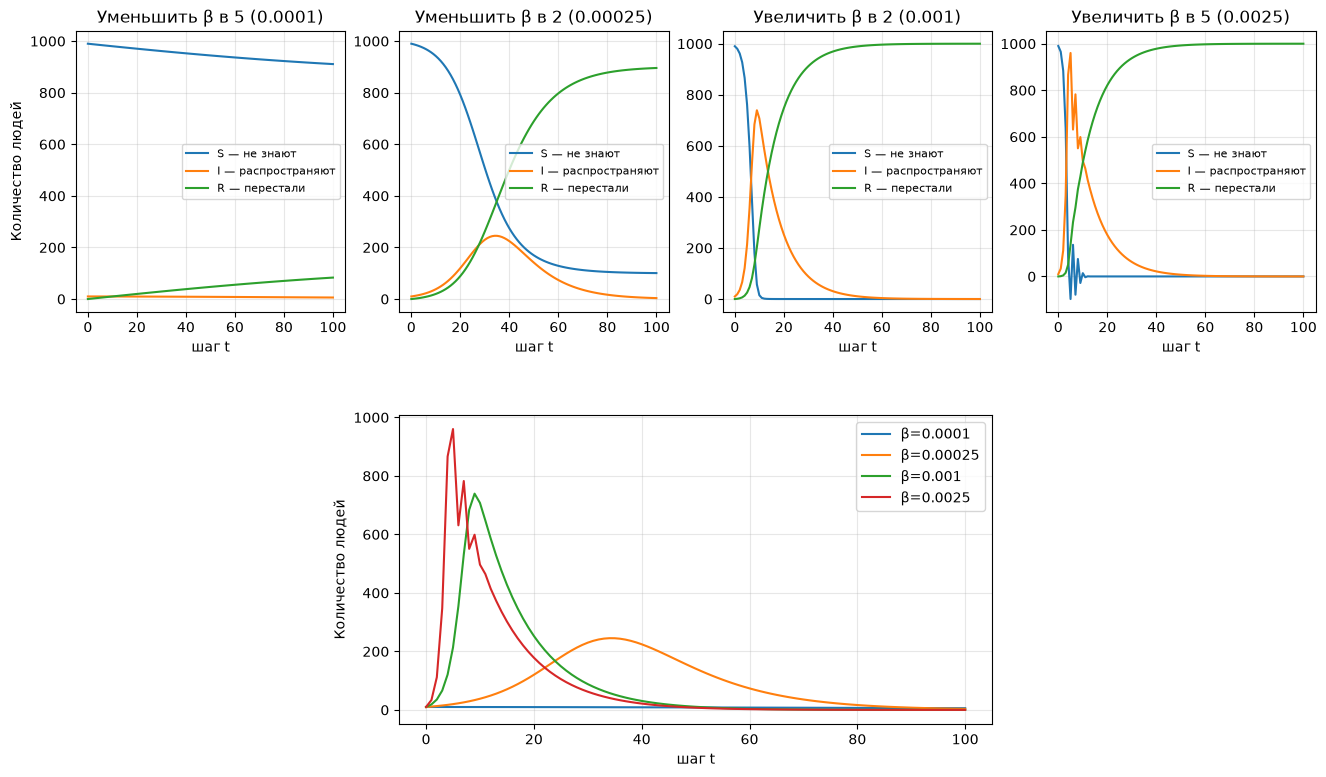

In [544]:
fig = plt.figure(figsize=(16, 9))
gs = GridSpec(2, 4, figure=fig, height_ratios=[1, 1.1], hspace=0.35)

for i, b in enumerate([beta/5, beta/2, beta*2, beta*5]):
    ax = fig.add_subplot(gs[0, i])
    
    S, I, R = simulate(b, gamma, S0, I0, R0, T)
    report(f"beta={b}", S, I)
    
    ax.plot(t, S, label="S — не знают")
    ax.plot(t, I, label="I — распространяют")
    ax.plot(t, R, label="R — перестали")
    
    ax.set_xlabel("шаг t")
    if beta / b > 1:
        ax.set_title(f"Уменьшить β в {beta/b:.0f} ({b})")
    else:
        ax.set_title(f"Увеличить β в {b/beta:.0f} ({b})")
    
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)
    
    if i == 0:
        ax.set_ylabel("Количество людей")

ax_compare = fig.add_subplot(gs[1, 1:3])

for b in [beta/5, beta/2, beta*2, beta*5]:
    S, I, R = simulate(b, gamma, S0, I0, R0, T)
    ax_compare.plot(t, I, label=f"β={b}")

ax_compare.set_xlabel("шаг t")
ax_compare.set_ylabel("Количество людей")
ax_compare.legend()
ax_compare.grid(alpha=0.3)

plt.show()

### 4.2 измените γ

gamma=0.02     пик I =  853.1 (шаг  17)   охват = 100.0%   I на шаге 100 =  167.1
gamma=0.05     пик I =  701.2 (шаг  17)   охват = 100.0%   I на шаге 100 =   11.2
gamma=0.2      пик I =  253.5 (шаг  18)   охват =  90.8%   I на шаге 100 =    0.0
gamma=0.5      пик I =   10.0 (шаг   0)   охват =  13.6%   I на шаге 100 =    0.0


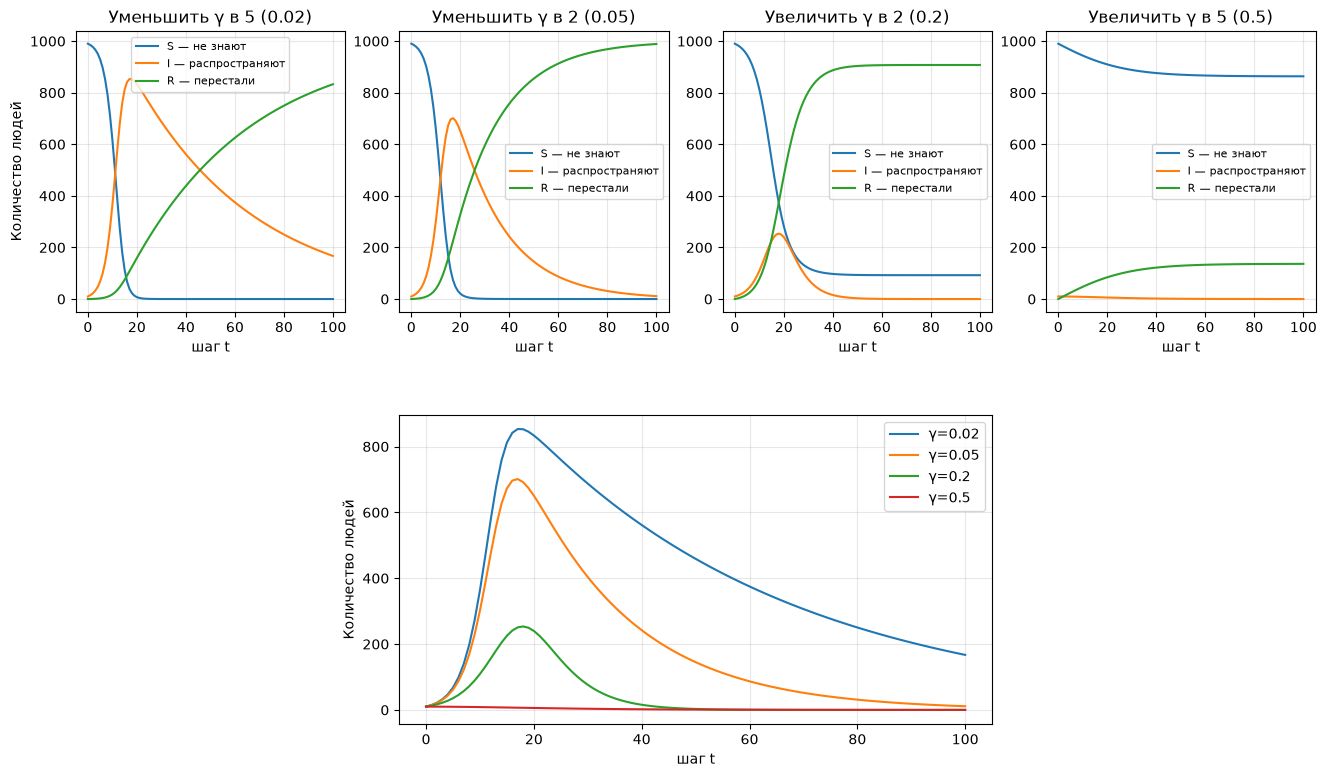

In [545]:
fig = plt.figure(figsize=(16, 9))
gs = GridSpec(2, 4, figure=fig, height_ratios=[1, 1.1], hspace=0.35)

for i, g in enumerate([gamma/5, gamma/2, gamma*2, gamma*5]):
    ax = fig.add_subplot(gs[0, i])
    
    S, I, R = simulate(beta, g, S0, I0, R0, T)
    report(f"gamma={g}", S, I)
    
    ax.plot(t, S, label="S — не знают")
    ax.plot(t, I, label="I — распространяют")
    ax.plot(t, R, label="R — перестали")
    
    ax.set_xlabel("шаг t")
    if gamma / g > 1:
        ax.set_title(f"Уменьшить γ в {gamma/g:.0f} ({g})")
    else:
        ax.set_title(f"Увеличить γ в {g/gamma:.0f} ({g})")
    
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)
    
    if i == 0:
        ax.set_ylabel("Количество людей")

ax_compare = fig.add_subplot(gs[1, 1:3])

for g in [gamma/5, gamma/2, gamma*2, gamma*5]:
    S, I, R = simulate(beta, g, S0, I0, R0, T)
    ax_compare.plot(t, I, label=f"γ={g}")

ax_compare.set_xlabel("шаг t")
ax_compare.set_ylabel("Количество людей")
ax_compare.legend()
ax_compare.grid(alpha=0.3)

plt.show()

### 4.3 измените начальное число информированных I0

I0=2.0         пик I =  506.9 (шаг  22)   охват =  99.6%   I на шаге 100 =    0.2
I0=5.0         пик I =  508.5 (шаг  19)   охват =  99.6%   I на шаге 100 =    0.2
I0=20          пик I =  511.1 (шаг  15)   охват =  99.6%   I на шаге 100 =    0.1
I0=50          пик I =  518.4 (шаг  12)   охват =  99.6%   I на шаге 100 =    0.1


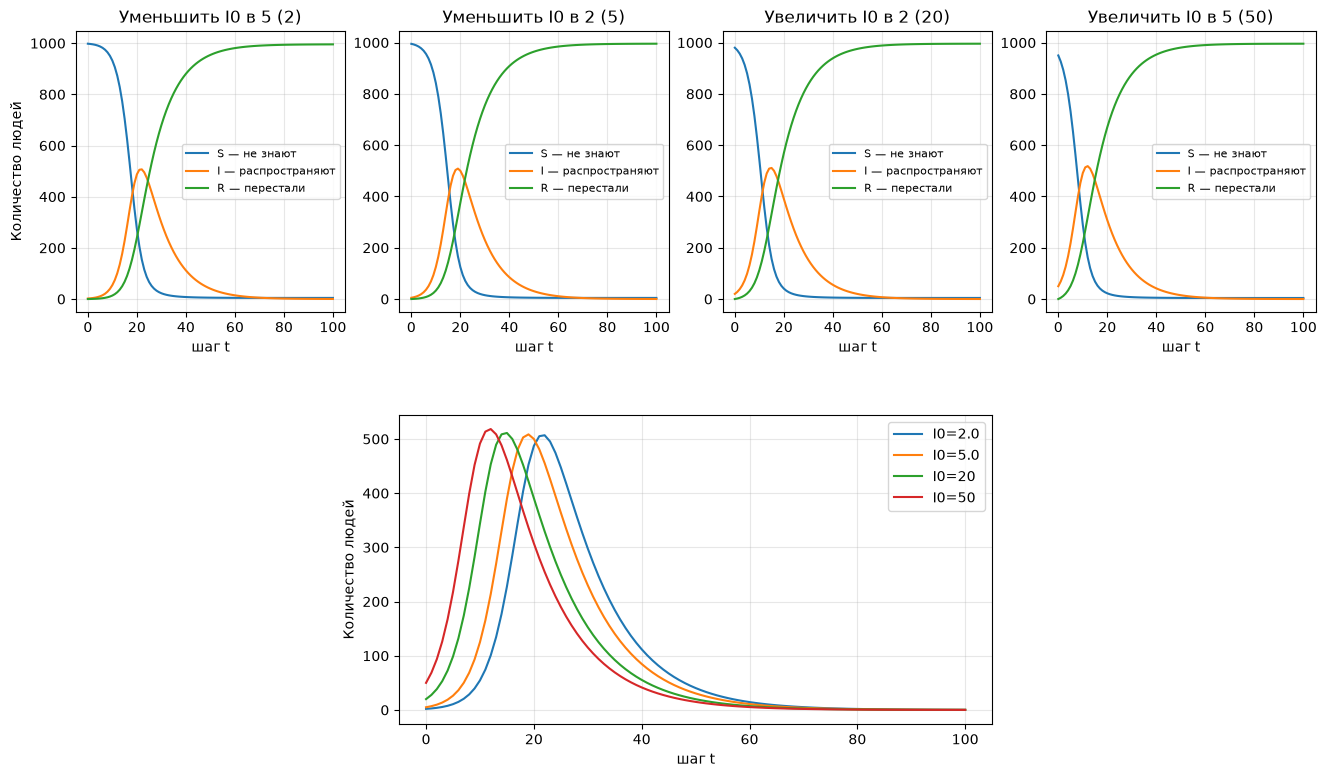

In [546]:
fig = plt.figure(figsize=(16, 9))
gs = GridSpec(2, 4, figure=fig, height_ratios=[1, 1.1], hspace=0.35)

for i, i0 in enumerate([I0/5, I0/2, I0*2, I0*5]):
    ax = fig.add_subplot(gs[0, i])
    
    S, I, R = simulate(beta, gamma, N - i0, i0, R0, T)
    report(f"I0={i0}", S, I)
    
    ax.plot(t, S, label="S — не знают")
    ax.plot(t, I, label="I — распространяют")
    ax.plot(t, R, label="R — перестали")
    
    ax.set_xlabel("шаг t")
    if I0 / i0 > 1:
        ax.set_title(f"Уменьшить I0 в {I0/i0:.0f} ({i0:.0f})")
    else:
        ax.set_title(f"Увеличить I0 в {i0/I0:.0f} ({i0:.0f})")
    
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)
    
    if i == 0:
        ax.set_ylabel("Количество людей")

ax_compare = fig.add_subplot(gs[1, 1:3])

for i0 in [I0/5, I0/2, I0*2, I0*5]:
    S, I, R = simulate(beta, gamma, N - i0, i0, R0, T)
    ax_compare.plot(t, I, label=f"I0={i0}")

ax_compare.set_xlabel("шаг t")
ax_compare.set_ylabel("Количество людей")
ax_compare.legend()
ax_compare.grid(alpha=0.3)

plt.show()

### 4.4 Как меняется динамика

- **β (коэффициент передачи).** Чем больше β, тем быстрее информация распространяется и тем выше пик. Доля охваченных при этом растёт. При уменьшении β в 5 раз информация почти не распространяется: пик равен начальным 10 людям, охват 8.9%.
- **γ (коэффициент затухания).** Влияет в обратную сторону: чем больше γ, тем быстрее люди перестают распространять информацию, поэтому пик ниже и охват меньше. При γ = 0.5 информация затухает сразу, охват 13.6%.
- **I₀ (начальное число информированных).** На итоговый охват почти не влияет (99.6% во всех случаях), но влияет на время: чем больше $I_0$, тем раньше наступает пик (шаг 22, 19, 15, 12 при $I_0$ = 2, 5, 20, 50). Высота пика при этом меняется слабо (от 507 до 518).

## 5. Кратко прокомментируйте результаты

- **При каких параметрах информация быстро затухает?** Когда β маленькое, а γ большое, то есть информация исчезает быстрее, чем успевает распространяться. Это хорошо видно при β/5 и при γ*5: пик остаётся равным начальным 10 людям, охват всего 8.9% и 13.6% (из них 1% составляют сами начальные распространяющие).
- **При каких параметрах охватывается большая часть сети?** Когда β достаточно большое, а γ небольшое.
- **Есть ли нежелательные режимы?**
  1. *Очень долгий «хвост».* При γ = 0.02 пик высокий (853), но на шаге 100 информацию всё ещё распространяют 167 человек, то есть за 100 шагов процесс не завершился. Похожая ситуация при γ = 0.05 (11 человек) и при β/5 (5.9 человека).
  2. *Некорректные значения при большом β.* При β×5 = 0.0025 число людей, не знающих информацию, становится отрицательным (на шаге 5), а это невозможно.

# Часть 2. Верификация

## 1. Проверьте инвариант
### 1.1 $S_t+I_t+R_t=N$ для всех $t$

Максимальное отклонение от N (абсолютное):    4.547473508864641e-13
Максимальное относительное отклонение:        4.547473508864641e-16
Верификация успешна (отклонение <= 1e-6):     True


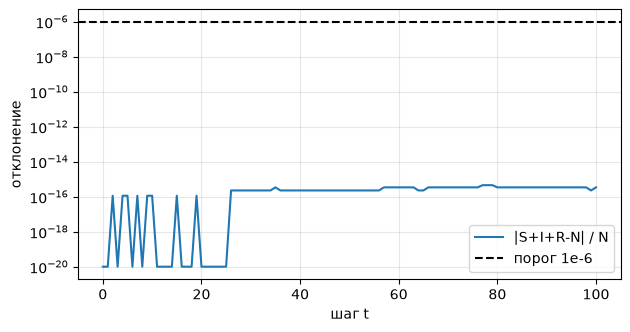

In [547]:
S, I, R = simulate(beta, gamma, S0, I0, R0, T)

отклонение = np.abs(S + I + R - N) / N
print("Максимальное отклонение от N (абсолютное):   ", np.max(np.abs(S + I + R - N)))
print("Максимальное относительное отклонение:       ", отклонение.max())
print("Верификация успешна (отклонение <= 1e-6):    ", отклонение.max() <= 1e-6)

plt.figure(figsize=(7, 3.5))
plt.semilogy(t, отклонение + 1e-20, label="|S+I+R-N| / N")
plt.axhline(1e-6, color="k", ls="--", label="порог 1e-6")
plt.xlabel("шаг t"); plt.ylabel("отклонение")
plt.legend(); plt.grid(alpha=0.3)
plt.show()

### 1.2 Значения $S_t, I_t, R_t$ остаются неотрицательными

Без ограничения шага (β=0.0025):
  минимальное S = -97.1 на шаге 5
  максимальное β·I = 2.40   (если > 1, множитель (1 - β·I) отрицательный)
  S+I+R всё равно равно N: True
  пик I = 960.1
С ограничением шага:
  минимальное S = 0.0
  пик I = 866.4 на шаге 4


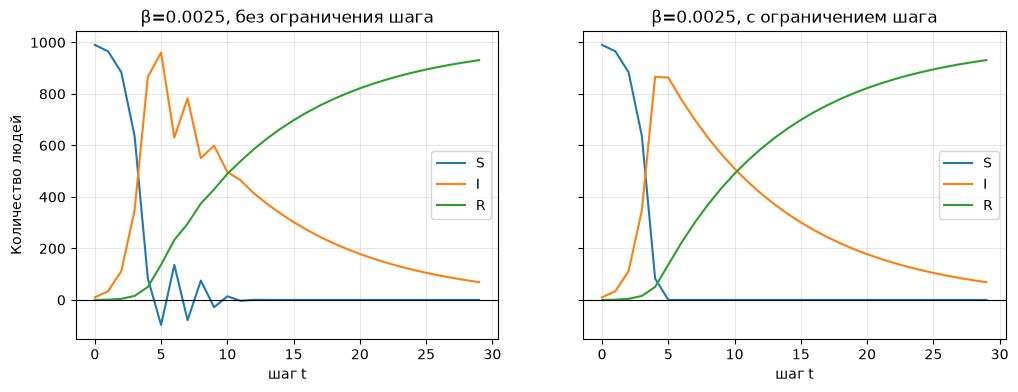

In [548]:
b = beta * 5

S, I, R = simulate(b, gamma, S0, I0, R0, T)                    # без ограничения шага
print(f"Без ограничения шага (β={b}):")
print(f"  минимальное S = {S.min():.1f} на шаге {S.argmin()}")
print(f"  максимальное β·I = {(b * I).max():.2f}   (если > 1, множитель (1 - β·I) отрицательный)")
print(f"  S+I+R всё равно равно N: {np.allclose(S + I + R, N)}")
print(f"  пик I = {I.max():.1f}")

S_ok, I_ok, R_ok = simulate(b, gamma, S0, I0, R0, T, safe=True)   # с ограничением шага
print("С ограничением шага:")
print(f"  минимальное S = {S_ok.min():.1f}")
print(f"  пик I = {I_ok.max():.1f} на шаге {I_ok.argmax()}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for ax, (s, i, r), title in zip(axes, [(S, I, R), (S_ok, I_ok, R_ok)], ["без ограничения шага", "с ограничением шага"]):
    ax.plot(t[:30], s[:30], label="S"); ax.plot(t[:30], i[:30], label="I"); ax.plot(t[:30], r[:30], label="R")
    ax.axhline(0, color="k", lw=0.8)
    ax.set_title(f"β={b}, {title}"); ax.set_xlabel("шаг t"); ax.legend(); ax.grid(alpha=0.3)
axes[0].set_ylabel("Количество людей")
plt.show()

### Выводы по инварианту и неотрицательности

- **Инвариант выполняется:** максимальное относительное отклонение $|S_t+I_t+R_t-N|/N$ равно $4.5\cdot10^{-16}$, это намного меньше порога $10^{-6}$. Верификация успешна.
- **Возможные причины отклонений.** Ошибки округления: числа с плавающей точкой хранятся приближённо, поэтому отклонение порядка $10^{-16}$ нормально.
- **Отрицательные значения.** При β×5 = 0.0025 значение $S$ уходит в минус на шаге 5 ($S\approx-97$). Причина: $S_{t+1}=S_t(1-\beta I_t)$, а к 4-му шагу $\beta I_t$ становится больше 1, поэтому множитель отрицателен. Иначе говоря, шаг по времени слишком крупный: формула «выводит» больше людей, чем их есть в группе. **Важно:** сумма $S+I+R$ при этом остаётся равной $N$, поэтому проверять нужно и сумму, и знак.
- **Исправление** — ограничить шаг: $\min(\beta S_tI_t,\,S_t)$, то есть новых информированных не может быть больше, чем осталось не знающих. Это включается параметром `safe=True`. После этого $S$ не опускается ниже 0, а корректный пик при β×5 равен 866 на шаге 4 (без ограничения получалось 960 на шаге 5, то есть искажённое значение).

## 2. Проверьте граничные случаи

I0=0:    max I = 0.0 | S всё время равно N: True
beta=0:  S не меняется: True | макс. расхождение I с теорией: 1.7763568394002505e-15
gamma=1: I на первых шагах: [10.    4.95  2.44  1.2   0.59] | охват: 2.0%


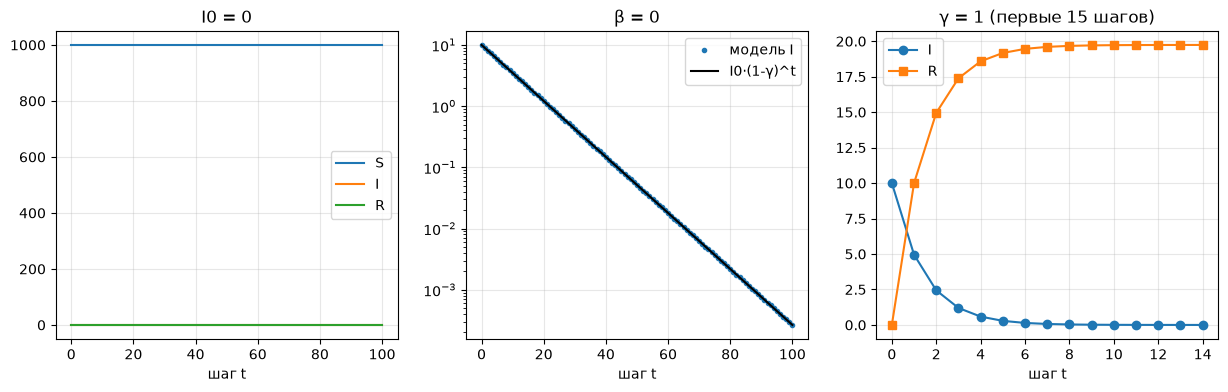

In [549]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

S, I, R = simulate(beta, gamma, N, 0, 0, T)
print("I0=0:    max I =", I.max(), "| S всё время равно N:", np.allclose(S, N))
axes[0].plot(t, S, label="S"); axes[0].plot(t, I, label="I"); axes[0].plot(t, R, label="R")
axes[0].set_title("I0 = 0")

S, I, R = simulate(0, gamma, S0, I0, R0, T)
теория = I0 * (1 - gamma) ** t
print("beta=0:  S не меняется:", np.allclose(S, S0), "| макс. расхождение I с теорией:", np.max(np.abs(I - теория)))
axes[1].semilogy(t, I, "o", ms=3, label="модель I")
axes[1].semilogy(t, теория, "k-", label="I0·(1-γ)^t")
axes[1].set_title("β = 0")

S, I, R = simulate(beta, 1, S0, I0, R0, T)
print("gamma=1: I на первых шагах:", np.round(I[:5], 2), "| охват:", f"{(N - S[-1]) / N:.1%}")
axes[2].plot(t[:15], I[:15], "o-", label="I"); axes[2].plot(t[:15], R[:15], "s-", label="R")
axes[2].set_title("γ = 1 (первые 15 шагов)")

for ax in axes:
    ax.set_xlabel("шаг t"); ax.legend(); ax.grid(alpha=0.3)
plt.show()

## 3. Сравните с предельными режимами

beta=1e-05: пик I = 10.0 на шаге 0, охват = 1.1%
beta=0.0005: пик I = 509.4 на шаге 17, охват = 99.6%
beta=0.005: пик I = 960.4 на шаге 3, охват = 100.0%


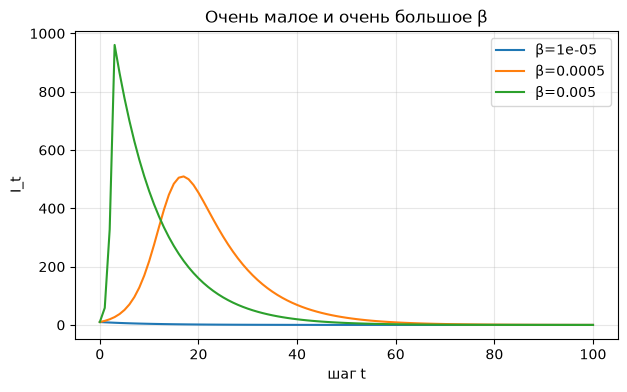

In [550]:
plt.figure(figsize=(7, 4))
for b in [0.00001, 0.0005, 0.005]:
    S, I, R = simulate(b, gamma, S0, I0, R0, T, safe=True)
    print(f"beta={b}: пик I = {I.max():.1f} на шаге {I.argmax()}, охват = {(N - S[-1]) / N:.1%}")
    plt.plot(t, I, label=f"β={b}")
plt.xlabel("шаг t"); plt.ylabel("I_t"); plt.title("Очень малое и очень большое β")
plt.legend(); plt.grid(alpha=0.3)
plt.show()

### Выводы по верификации

- **I₀ = 0:** ничего не происходит, как и должно быть.
- **β = 0:** новых информированных нет, $S_t$ постоянно, а $I_t$ совпадает с $I_0(1-\gamma)^t$ (расхождение порядка $10^{-15}$).
- **γ = 1:** каждый распространяющий «живёт» один шаг, поэтому $I_t$ быстро обрывается ($10\to4.95\to2.44\to\dots$), охват всего 2%.
- **Очень малое β = 0.00001:** охват 1.1%, то есть только начальный 1% плюс почти никого нового: распространение фактически отсутствует.
- **Очень большое β = 0.005:** все охвачены уже к 3-му шагу (пик 960). Оба предельных режима соответствуют интуиции: чем больше β, тем быстрее и полнее охват.

Итог: реализация корректна: инвариант выполняется с точностью $10^{-16}$, граничные случаи и предельные режимы ведут себя ожидаемо, а проблема отрицательных значений при большом β объяснена и исправлена ограничением шага.

# Часть 3. Валидация (упрощённая)


## 1. Сгенерируйте «псевдореальные» данные
Берём модель с известными параметрами $\beta^*, \gamma^*$, получаем траекторию $I_t$ и добавляем гауссовский шум.

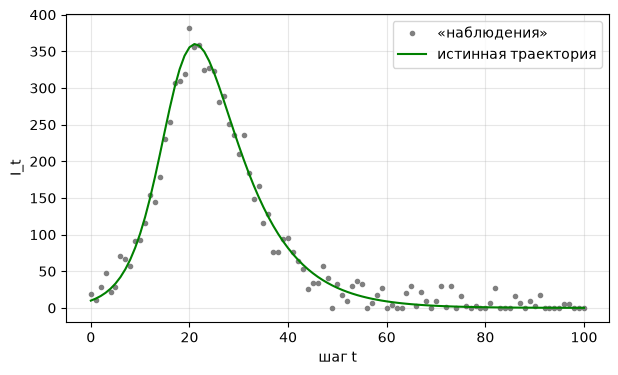

In [ ]:
beta_true, gamma_true = 0.0004, 0.12

np.random.seed(42)
_, I_true, _ = simulate(beta_true, gamma_true, S0, I0, R0, T)
шум = np.random.normal(0, 0.05 * I_true.max(), size=T + 1)
I_obs = np.clip(I_true + шум, 0, None)

plt.figure(figsize=(7, 4))
plt.plot(t, I_obs, "o", ms=3, color="gray", label="«наблюдения»")
plt.plot(t, I_true, "g-", label="истинная траектория")
plt.xlabel("шаг t"); plt.ylabel("I_t"); plt.legend(); plt.grid(alpha=0.3)
plt.show()

## 2. Подберите параметры перебором по сетке
β от 0.0001 до 0.001 с шагом 0.0001, γ от 0.05 до 0.2 с шагом 0.01. Для каждой пары считаем среднеквадратичную ошибку между моделью и «наблюдениями» и выбираем пару с минимальной ошибкой.

Найдено: beta = 0.0004, gamma = 0.12   (истинные: 0.0004, 0.12)
Среднеквадратичная ошибка (RMSE) = 14.36 человек


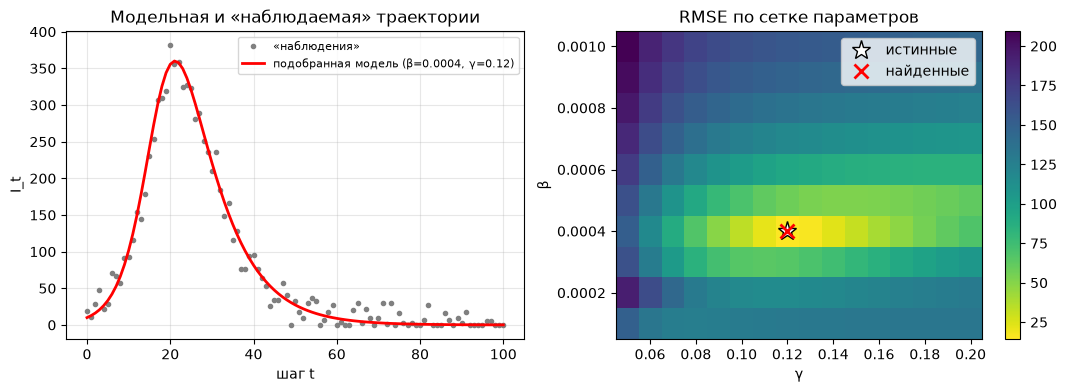

In [ ]:
betas = np.arange(1, 11) * 0.0001              # 0.0001 ... 0.001
gammas = np.arange(5, 21) * 0.01               # 0.05 ... 0.20

mse = np.zeros((len(betas), len(gammas)))
I_models = np.zeros((len(betas), len(gammas), T + 1))
for i, b in enumerate(betas):
    for j, g in enumerate(gammas):
        _, I_model, _ = simulate(b, g, S0, I0, R0, T, safe=True)
        I_models[i, j] = I_model
        mse[i, j] = np.mean((I_model - I_obs) ** 2)

i, j = np.unravel_index(np.argmin(mse), mse.shape)
beta_fit, gamma_fit = betas[i], gammas[j]
print(f"Найдено: beta = {beta_fit:.4f}, gamma = {gamma_fit:.2f}   (истинные: {beta_true}, {gamma_true})")
print(f"Среднеквадратичная ошибка (RMSE) = {np.sqrt(mse[i, j]):.2f} человек")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(t, I_obs, "o", ms=3, color="gray", label="«наблюдения»")
axes[0].plot(t, I_models[i, j], "r-", lw=2, label=f"подобранная модель (β={beta_fit:.4f}, γ={gamma_fit:.2f})")
axes[0].set_xlabel("шаг t"); axes[0].set_ylabel("I_t"); axes[0].legend(loc="upper right", fontsize=8); axes[0].grid(alpha=0.3)
axes[0].set_title("Модельная и «наблюдаемая» траектории")

im = axes[1].imshow(np.sqrt(mse), origin="lower", aspect="auto", cmap="viridis_r",
                    extent=[gammas[0] - 0.005, gammas[-1] + 0.005, betas[0] - 0.00005, betas[-1] + 0.00005])
axes[1].plot(gamma_true, beta_true, "w*", ms=14, mec="k", label="истинные")
axes[1].plot(gamma_fit, beta_fit, "rx", ms=10, mew=2, label="найденные")
axes[1].set_xlabel("γ"); axes[1].set_ylabel("β"); axes[1].set_title("RMSE по сетке параметров")
axes[1].legend(); plt.colorbar(im, ax=axes[1])
plt.show()

Повторяем эксперимент 200 раз для каждого уровня шума и смотрим, как часто находятся истинные параметры.

In [553]:
for уровень in [0.02, 0.05, 0.10, 0.20]:
    beta_ok = gamma_ok = 0
    for k in range(200):
        obs = np.clip(I_true + np.random.normal(0, уровень * I_true.max(), T + 1), 0, None)
        err = np.mean((I_models - obs) ** 2, axis=2)            # ошибка для всех 160 пар сразу
        a, b = np.unravel_index(np.argmin(err), err.shape)
        beta_ok += abs(betas[a] - beta_true) < 1e-9
        gamma_ok += abs(gammas[b] - gamma_true) < 1e-9
    print(f"шум {уровень:4.0%} от пика: β найдено верно в {beta_ok / 200:.0%} запусков, γ — в {gamma_ok / 200:.0%}")

шум   2% от пика: β найдено верно в 100% запусков, γ — в 100%
шум   5% от пика: β найдено верно в 100% запусков, γ — в 100%
шум  10% от пика: β найдено верно в 100% запусков, γ — в 90%
шум  20% от пика: β найдено верно в 100% запусков, γ — в 62%


## 3. Кратко опишите

- **Результат подбора:** найдены $\beta=0.0004$, $\gamma=0.12$, они совпали с истинными. RMSE ≈ 14 человек, это уровень самого шума (σ ≈ 18 человек), то есть точнее при таких данных получить нельзя.
- **Насколько успешно удалось восстановить параметры:** при шуме до 5% параметры находятся точно в 100% запусков; при 10% γ находится верно в 90%, при 20% — в 62%. Параметр β находится верно всегда. Параметр γ влияет в основном на спад, где значения малы и шум заметнее.
- **Трудности:** (1) сетка дискретна: если истинные параметры лежат между узлами, найдётся только ближайший узел; (2) шум ухудшает оценку; (3) наблюдается только $I_t$, а $S_t$ и $R_t$ не видны; (4) β и γ частично компенсируют друг друга (на карте ошибки минимум вытянут вдоль γ).
- **Как выглядела бы валидация на реальных данных:** шум был бы не гауссовским, в данных были бы пропуски и задержки, а параметры могли бы меняться со временем.